<a href="https://colab.research.google.com/github/SoumyadeepChattopadhyay2004/Real-Time-IPL-Win-Predictor/blob/main/Real_Time_IPL_Win_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
pip install xgboost

In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

In [51]:
df = pd.read_csv("/content/IPL.csv", low_memory=False)

print(df.shape)
df.head()

(278205, 64)


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [52]:
df = df[df['innings'] == 2]

In [53]:
df['current_score'] = df['team_runs']

In [54]:
df['runs_left'] = df['runs_target'] - df['current_score']

In [55]:
df['balls_left'] = 120 - df['ball_no']
df['balls_left'] = df['balls_left'].clip(lower=0)

In [56]:
df['wickets_left'] = 10 - df['team_wicket']

In [57]:
df['overs_completed'] = df['ball_no'] / 6

In [58]:
df['current_run_rate'] = df['current_score'] / df['overs_completed']
df['current_run_rate'] = df['current_run_rate'].replace([np.inf],0)

In [59]:
df['required_run_rate'] = (df['runs_left'] * 6) / df['balls_left']
df['required_run_rate'] = df['required_run_rate'].replace([np.inf],0)

In [60]:
df['required_run_rate'] = (df['runs_left'] * 6) / df['balls_left']
df['required_run_rate'] = df['required_run_rate'].replace([np.inf],0)

In [61]:
df['result'] = df['win_outcome'].apply(
    lambda x: 1 if x == "batting" else 0
)

In [62]:
model_df = df[[
'batting_team',
'bowling_team',
'venue',
'runs_left',
'balls_left',
'wickets_left',
'current_run_rate',
'required_run_rate',
'result'
]]

In [63]:
model_df = model_df.dropna()

In [64]:
X = model_df.drop('result', axis=1)
y = model_df['result']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
categorical_features = ['batting_team','bowling_team','venue']

transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [67]:
xgb_model = Pipeline([
    ('transformer', transformer),
    ('model', XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['batting_team',
                                                   'bowling_team',
                                                   'venue'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=No...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=8, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [68]:
predictions = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26781

    accuracy                           1.00     26781
   macro avg       1.00      1.00      1.00     26781
weighted avg       1.00      1.00      1.00     26781



In [69]:
sample = X_test.iloc[0:1]

prob = xgb_model.predict_proba(sample)

print("Lose Probability:", prob[0][0])
print("Win Probability:", prob[0][1])

Lose Probability: 0.999999
Win Probability: 9.999998e-07


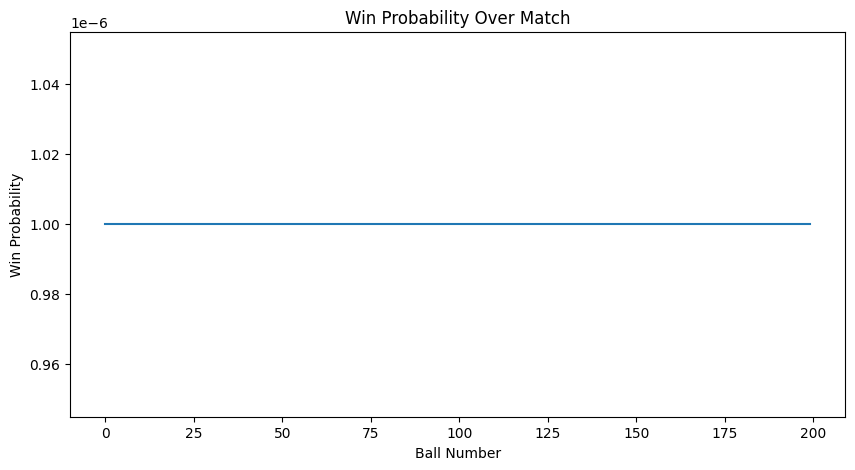

In [70]:
match_example = model_df.iloc[:200]

probs = xgb_model.predict_proba(
    match_example.drop('result',axis=1)
)[:,1]

plt.figure(figsize=(10,5))

plt.plot(probs)

plt.title("Win Probability Over Match")

plt.xlabel("Ball Number")

plt.ylabel("Win Probability")

plt.show()